In [3]:
import numpy as nb
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
df=pd.read_csv(r"C:\Users\sarthak\OneDrive\Desktop\Student Result Analysis\data set\student_score.csv")

In [6]:
import os
print(os.getcwd())

c:\Users\sarthak\OneDrive\Desktop\Student Result Analysis\EDA


In [7]:
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [9]:
df.describe()


,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [12]:
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

# drop unname column

In [19]:
df = df.drop("Unnamed: 0",axis=1)


KeyError: "['Unnamed: 0'] not found in axis"

In [20]:
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


# change the 5-10 oct weeklystudyhours

In [21]:
df["WklyStudyHours"]=df["WklyStudyHours"].str.replace("5-10 Oct","5-10")
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


# Gender Count

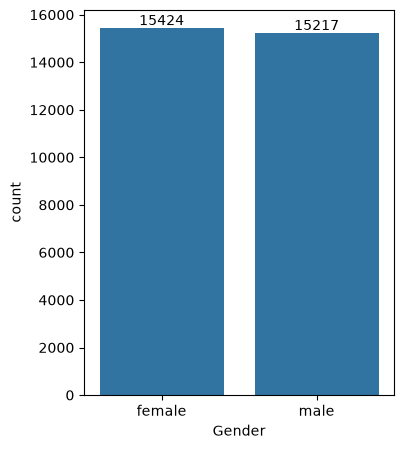

In [ ]:

plt.figure(figsize=(4,5))
ax=sns.countplot(data= df,x="Gender")
ax.bar_label(ax.containers[0])
plt.show()

Gender Distribution

This countplot shows the number of male vs. female students in the dataset.

Female students slightly outnumber male students, though the dataset remains reasonably balanced overall.

Takeaway: Since neither gender group is too small, any later comparison of scores by gender can be considered statistically reliable.

# Parents Education vs Student Score

In [33]:
gb= df.groupby("ParentEduc").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
education_order = [
    "master's degree",
    "bachelor's degree",
    "associate's degree",
    'some college',
    'high school',
    'some high school'
]
gb=gb.reindex(education_order)
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
master's degree     72.336134     75.832921     76.356896
bachelor's degree   70.466627     73.062020     73.331069
associate's degree  68.365586     71.124324     70.299099
some college        66.390472     69.179708     68.501432
high school         64.435731     67.213997     65.421136
some high school    62.584013     65.510785     63.632409


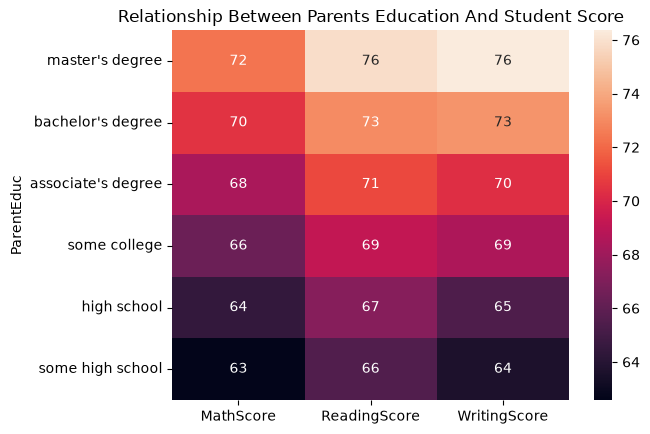

In [36]:

sns.heatmap(gb , annot= True)
plt.title('Relationship Between Parents Education And Student Score')
plt.show()


Parent Education vs Student Score


This heatmap shows average Math, Reading, and Writing scores grouped by parent education level, ordered from lowest to highest qualification.

Scores show a clear upward trend as parent education level increases: students whose parents have only some high school education average the lowest scores (63–66), while students whose parents hold a master's degree average the highest (72–76).
The jump is most visible in Reading and Writing scores, which rise by ~10 points from the lowest to highest education group, compared to Math which rises by about 9 points.

Takeaway: Parent education level has a strong, consistent positive relationship with student performance across all three subjects — making it one of the most influential factors identified in this analysis so far.

# Sports Practice vs Student Score

In [ ]:
gb1=df.groupby('PracticeSport').agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
correct_order=[
    "regularly",
    "sometimes",
    "never"
]
gb1=gb1.reindex(correct_order)
print(gb1)

               MathScore  ReadingScore  WritingScore
PracticeSport                                       
regularly      67.839155     69.943019     69.604003
sometimes      66.274831     69.241307     68.072438
never          64.171079     68.337662     66.522727


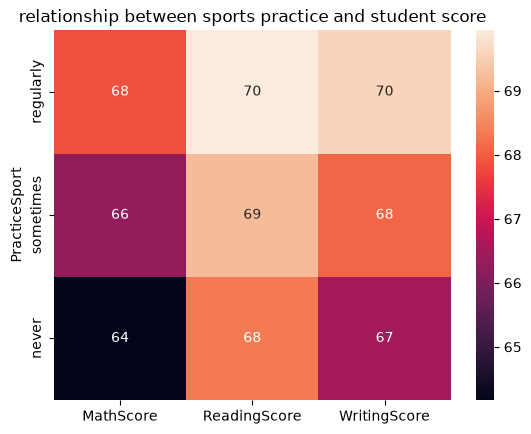

In [ ]:
sns.heatmap(gb1,annot=True)
plt.title("relationship between sports practice and student score")
plt.show()

Sports Practice vs Student Score  


This heatmap compares average scores across students who practice sports regularly, sometimes, or never.

Students who practice sports regularly show the highest average scores, while students who never play sports show the lowest.
The gap between "regularly" and "never" groups, while smaller than the Parent Education effect, is still noticeable across all three subjects.

Takeaway: Regular physical activity is associated with better academic performance, possibly tied to discipline, routine, or overall well-being. This is a correlation, not proof of causation — but it's a meaningful pattern worth highlighting.

# Siblings vs Student Score

In [82]:
gb2=df.groupby('NrSiblings').agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb2)

            MathScore  ReadingScore  WritingScore
NrSiblings                                       
0.0         66.819449     69.547812     68.746515
1.0         66.473896     69.259097     68.245345
2.0         66.554934     69.472018     68.522533
3.0         66.719092     69.488159     68.650498
4.0         66.245495     69.144169     68.073444
5.0         66.630303     69.453788     68.282576
6.0         65.917219     68.801325     67.860927
7.0         67.615120     69.828179     68.986254


Text(0.5, 1.0, 'Relationship between siblings and student score')

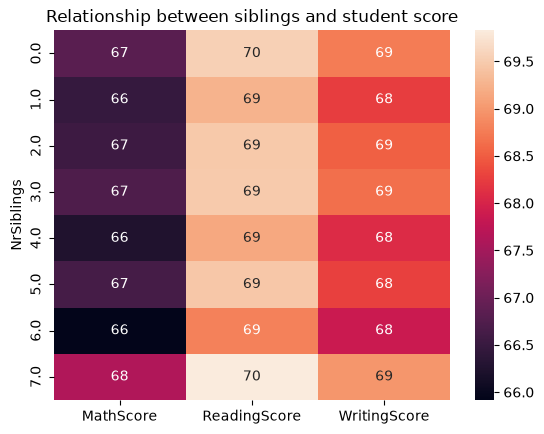

In [85]:
sns.heatmap(gb2,annot=True)
plt.title("Relationship between siblings and student score")

Siblings vs Subject Scores


This heatmap shows the average Math, Reading, and Writing scores for students grouped by number of siblings (0–7).

All three subjects stay remarkably stable across every sibling count — Math ranges narrowly between 65.9–67.6, Reading between 68.8–69.8, and Writing between 67.9–69.0.
Students with 6 siblings show the slight lowest averages across all three subjects, while those with 7 siblings show the highest — but the overall spread is so small (just 1–2 points) that this isn't a meaningful trend.

Takeaway: Number of siblings has no real impact on academic performance — scores stay flat regardless of family size. This is a useful negative finding: it tells the client which factors don't drive performance, helping focus attention on the ones that actually do (like Parent Education or Sports Practice).

# Outlier Detection 

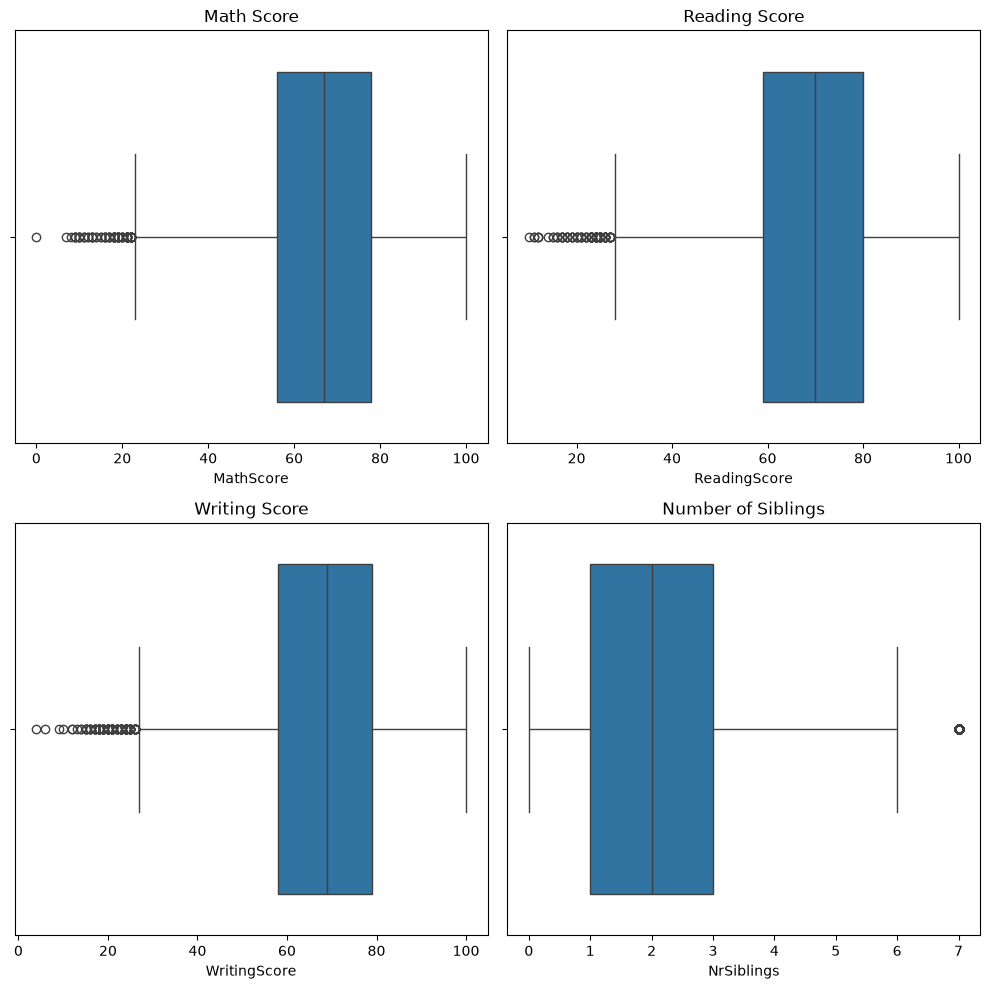

In [50]:
plt.figure(figsize=(10,10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='MathScore')
plt.title('Math Score')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='ReadingScore')
plt.title('Reading Score')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='WritingScore')
plt.title('Writing Score')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='NrSiblings')
plt.title('Number of Siblings')

plt.tight_layout()
plt.show()

Outlier Detection — Scores & Siblings
The boxplots highlight how scores and sibling counts are distributed, along with any unusual values.

MathScore, ReadingScore, and WritingScore all follow a similar pattern — most students score between 55–80, but each subject has a small cluster of low-score outliers (below ~25). No high-end outliers were found, meaning top scores stay within the expected range.
NrSiblings is fairly evenly spread between 0–3, with one outlier at 7 siblings — a value far higher than the rest of the students.

Takeaway: A small group of students consistently scored unusually low across all three subjects — these cases are worth flagging separately, as they could be genuine low performers or potential data entry issues. The single sibling-count outlier is likely just a rare case and doesn't affect the overall trend.

In [52]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


# EthnicGroup Distribution

In [79]:
groupA=df.loc[df['EthnicGroup']=='group A'].count()
groupB=df.loc[df['EthnicGroup']=='group B'].count()
groupC=df.loc[df['EthnicGroup']=='group C'].count()
groupD=df.loc[df['EthnicGroup']=='group D'].count()
groupE=df.loc[df['EthnicGroup']=='group E'].count()


In [80]:
fr= df["EthnicGroup"].unique()
fr

<ArrowStringArray>
[nan, 'group C', 'group B', 'group A', 'group D', 'group E']
Length: 6, dtype: str

Text(0.5, 1.0, 'EthnicGroup Distribution')

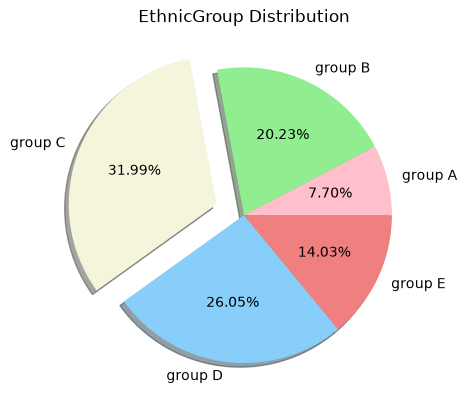

In [86]:
ethlist=[groupA["EthnicGroup"],groupB["EthnicGroup"],groupC ["EthnicGroup"],groupD["EthnicGroup"],groupE["EthnicGroup"]]
col=['pink','lightgreen','beige','lightskyblue','lightcoral']
lbl=["group A","group B","group C","group D","group E"]
plt.pie(ethlist,colors=col,shadow=True,autopct="%1.2f%%",labels=lbl,explode=(0,0,0.2,0,0))
plt.title('EthnicGroup Distribution')


Ethnic Group Distribution

The student population is spread across 5 ethnic groups, but not evenly.

Group C is the largest, making up nearly a third (32%) of all students.
Group D (26%) and Group B (20%) form the next biggest segments.
Group A is the smallest, at just 7.7% — under half the size of any other group.

Takeaway: The sample is skewed toward Groups C and D, who together represent over half the dataset. Group A's small size means any conclusions drawn specifically about that group should be treated with a bit of caution, since it's based on fewer students.

# Coorelation Between Scores 

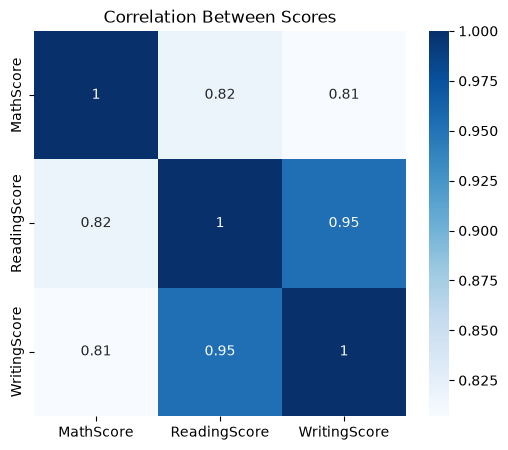

In [78]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['MathScore','ReadingScore','WritingScore']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Between Scores')
plt.show()

Correlation Between Scores
All three subjects show strong positive correlation, meaning students who perform well in one subject tend to perform well in the others too.

ReadingScore & WritingScore have the strongest relationship (0.95) — students who read well almost always write well, which makes sense since both are language-based skills.
MathScore correlates a bit less strongly with Reading (0.82) and Writing (0.81) — math is a more independent skill set compared to the tightly linked language scores.

Takeaway: Reading and Writing skills move together almost in lockstep, while Math performance, though still related, is a somewhat distinct skill.

# Test Prep Completion vs Student Score

           MathScore  ReadingScore  WritingScore
TestPrep                                        
completed   69.54666     73.732998     74.703265
none        64.94877     67.051071     65.092756


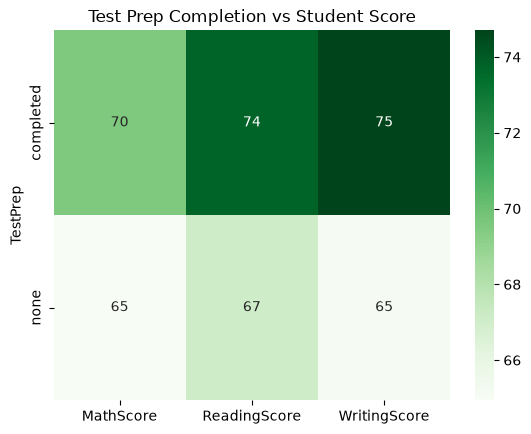

In [87]:
gb3 = df.groupby('TestPrep').agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb3)

sns.heatmap(gb3, annot=True, cmap='Greens')
plt.title("Test Prep Completion vs Student Score")
plt.show()

This heatmap compares average Math, Reading, and Writing scores between students who completed test prep and those who didn't.

Students who completed test prep scored noticeably higher across all three subjects: Math 70, Reading 74, Writing 75.
Students with no test prep averaged lower: Math 65, Reading 67, Writing 65.
The gap is most visible in Writing (+10 points), followed by Reading (+7 points) and Math (+5 points).

Takeaway: Completing test prep is associated with a meaningful score boost across all subjects, with the strongest effect on Writing. This makes Test Prep one of the most impactful factors identified in this analysis — comparable to, or even stronger than, Parent Education in some subjects.

# Test Prep Completion Count

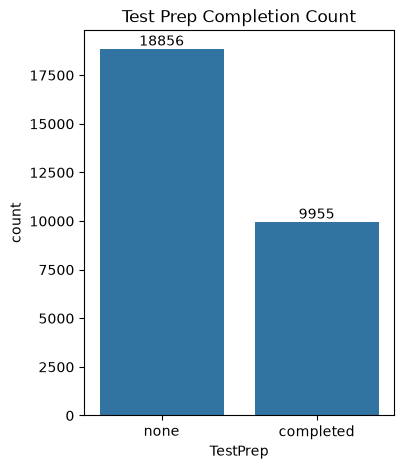

In [88]:
plt.figure(figsize=(4,5))
ax = sns.countplot(data=df, x="TestPrep")
ax.bar_label(ax.containers[0])
plt.title("Test Prep Completion Count")
plt.show()

Test Prep Completion Count


This countplot shows how many students completed test prep versus those who didn't.

18,856 students (≈65%) did not complete test prep.
Only 9,955 students (≈35%) completed test prep.

Takeaway: Nearly two-thirds of students skipped test prep entirely. This context matters for the previous heatmap — even though the "completed" group showed clearly higher scores, that conclusion is based on a smaller sample size (roughly a third of the dataset). It still strengthens the case that test prep helps, but it also highlights an opportunity: if more students completed prep, overall scores could potentially rise as well.

# Final Conclusions


This analysis examined 30,641 students across multiple factors to identify what actually influences academic performance.
Overall averages: Math 66.6, Reading 69.4, Writing 68.4 — Reading and Writing students typically score a few points higher than Math.
Factors that strongly influence scores:

Parent Education — the single biggest factor identified. Scores rise steadily from "some high school" parents (lowest) to "master's degree" parents (highest), with up to a 10-point gap in Reading/Writing.
Test Prep Completion — students who completed prep scored 5–10 points higher across all subjects, with the strongest boost in Writing. Only 35% (9,955) of students completed prep, while 65% (18,856) didn't — suggesting real room for improvement if more students took it up.
Sports Practice — students who play sports regularly outperform those who never do, though the gap is smaller than Parent Education or Test Prep.

Factors with little to no effect:

Number of Siblings — scores stayed flat (within 1–2 points) regardless of family size, ruling this out as a meaningful driver.

Other observations:

Gender is nearly balanced (15,424 female vs 15,217 male), so any gender-based comparison in this dataset is statistically reliable.
Reading and Writing scores are tightly correlated (0.95) — students strong in one are almost always strong in the other — while Math is more independent (0.81–0.82 correlation with the others), suggesting it draws on a different skill set.
Ethnic Group distribution is uneven: Groups C (32%) and D (26%) make up over half the student population, while Group A is the smallest (7.7%).
A small cluster of students consistently scored low across all three subjects, flagged as outliers worth a closer look — possibly genuine low performers or data entry issues.

Bottom line: Parent education and test prep completion are the strongest predictors of student performance, while family size has no measurable impact. If the goal is improving outcomes, focusing resources on test prep accessibility — since two-thirds of students currently skip it — could be the most actionable lever to raise scores broadly.